In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset (asegúrate que el archivo esté en la misma carpeta)
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Eliminar columnas irrelevantes para la predicción
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

# Convertir la variable objetivo 'Attrition' a numérica (Yes=1, No=0)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Convertir variables categóricas a numéricas (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)

# Guardar para usar en Power BI
df.to_csv('HR_Data_Cleaned.csv', index=False)
print("Datos limpios y guardados.")

Datos limpios y guardados.


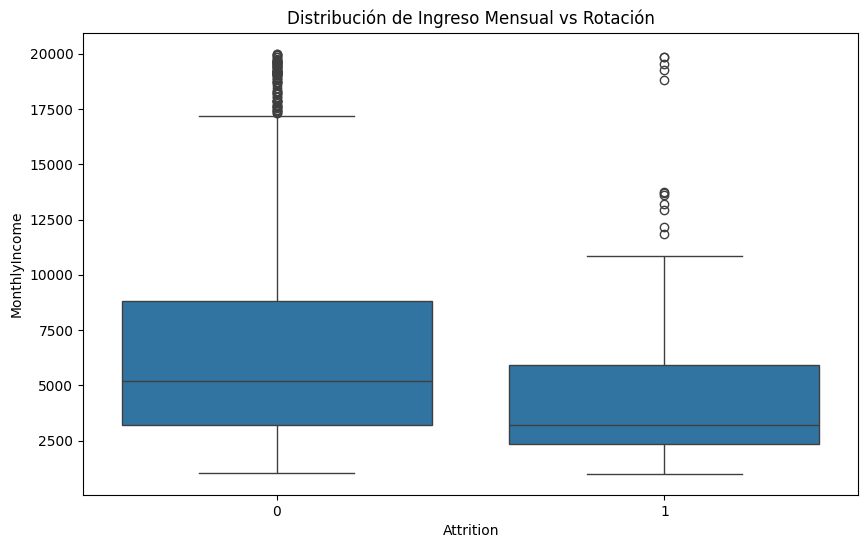

In [4]:
# Relación entre Ingresos y Rotación
plt.figure(figsize=(10,6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Distribución de Ingreso Mensual vs Rotación')
plt.show()


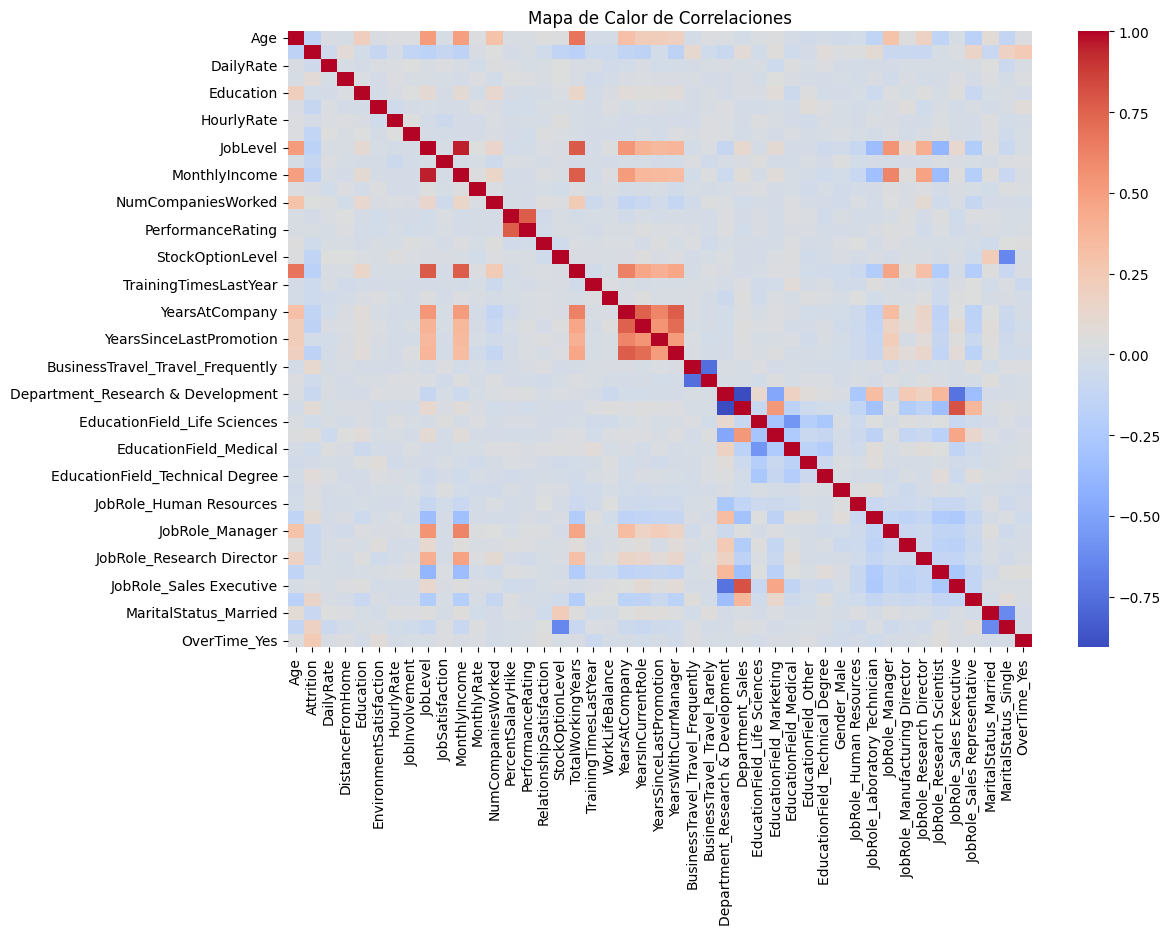

In [5]:
# Correlación de variables (ayuda a ver qué afecta más la rotación)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Definir variables
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Dividir datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicciones y resultados
y_pred = rf.predict(X_test)

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



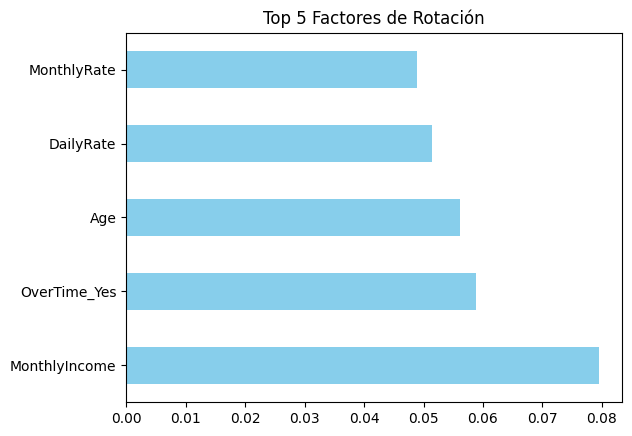

In [7]:
# Mostrar las 5 variables que más influyen en que alguien renuncie
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='skyblue')
plt.title('Top 5 Factores de Rotación')
plt.show()